# Task 2 — Model Building and Training
**Adey Innovations Inc. | Fraud Detection | Week 5 & 6**

**Objective:** Train and compare Logistic Regression, Random Forest, and XGBoost on both fraud datasets. Select the best model per dataset based on PR-AUC and F1-Score.

---

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

BLUE='#2E75B6'; CORAL='#E95D4F'; GREEN='#70AD47'; AMBER='#FFC000'; DARK='#1F3864'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False,
                      'font.family': 'DejaVu Sans'})
RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../notebooks/figures', exist_ok=True)
print('Setup complete.')

Setup complete.


---
## 1. Load Processed Datasets

In [2]:
fraud = pd.read_csv('../data/processed/fraud_data_processed.csv')
cc    = pd.read_csv('../data/processed/creditcard_processed.csv')

print(f'Fraud_Data shape: {fraud.shape} | Fraud rate: {fraud["class"].mean()*100:.2f}%')
print(f'creditcard shape: {cc.shape}    | Fraud rate: {cc["Class"].mean()*100:.4f}%')

X_fraud = fraud.drop(columns=['class'])
y_fraud = fraud['class']

X_cc = cc.drop(columns=['Class'])
y_cc = cc['Class']

print(f'\nFraud_Data features: {X_fraud.shape[1]}')
print(f'creditcard features: {X_cc.shape[1]}')

Fraud_Data shape: (151112, 19) | Fraud rate: 9.36%
creditcard shape: (283726, 31)    | Fraud rate: 0.1667%

Fraud_Data features: 18
creditcard features: 30


---
## 2. Train-Test Split (Stratified)

In [3]:
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
    X_fraud, y_fraud, test_size=0.20, stratify=y_fraud, random_state=RANDOM_STATE)

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_cc, y_cc, test_size=0.20, stratify=y_cc, random_state=RANDOM_STATE)

print('Fraud_Data split:')
print(f'  Train: {len(X_f_train):,} | fraud={y_f_train.mean()*100:.2f}%')
print(f'  Test:  {len(X_f_test):,}  | fraud={y_f_test.mean()*100:.2f}%')
print()
print('creditcard split:')
print(f'  Train: {len(X_c_train):,} | fraud={y_c_train.mean()*100:.4f}%')
print(f'  Test:  {len(X_c_test):,}  | fraud={y_c_test.mean()*100:.4f}%')

Fraud_Data split:
  Train: 120,889 | fraud=9.36%
  Test:  30,223  | fraud=9.36%

creditcard split:
  Train: 226,980 | fraud=0.1665%
  Test:  56,746  | fraud=0.1674%


---
## 3. Apply SMOTE to Training Sets Only

In [4]:
smote = SMOTE(random_state=RANDOM_STATE)

X_f_train_sm, y_f_train_sm = smote.fit_resample(X_f_train, y_f_train)
print(f'Fraud_Data after SMOTE: {dict(zip(*np.unique(y_f_train_sm, return_counts=True)))}')

X_c_train_sm, y_c_train_sm = smote.fit_resample(X_c_train, y_c_train)
print(f'creditcard after SMOTE: {dict(zip(*np.unique(y_c_train_sm, return_counts=True)))}')

Fraud_Data after SMOTE: {np.int64(0): np.int64(109568), np.int64(1): np.int64(109568)}
creditcard after SMOTE: {np.int64(0): np.int64(226602), np.int64(1): np.int64(226602)}


---
## 4. Model Definitions

In [5]:
def get_models(scale_pos_weight=9):
    return {
        'LogisticRegression': LogisticRegression(
            C=0.1, max_iter=1000, class_weight='balanced',
            solver='lbfgs', random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, max_depth=10, min_samples_leaf=20,
            class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric='aucpr', verbosity=0,
            random_state=RANDOM_STATE),
    }

def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    return {
        'roc_auc': roc_auc_score(y_test, y_prob),
        'pr_auc':  average_precision_score(y_test, y_prob),
        'f1':      f1_score(y_test, y_pred, zero_division=0),
        'y_pred':  y_pred, 'y_prob': y_prob,
        'cm':      confusion_matrix(y_test, y_pred),
        'report':  classification_report(y_test, y_pred, zero_division=0),
    }

print('Model definitions ready.')

Model definitions ready.


---
## 5. Train and Evaluate — Fraud_Data.csv

In [6]:
fraud_results = {}
fraud_models  = get_models(scale_pos_weight=9)

for name, model in fraud_models.items():
    print(f'Training {name} on Fraud_Data ...')
    model.fit(X_f_train_sm, y_f_train_sm)
    res = evaluate(model, X_f_test, y_f_test)
    fraud_results[name] = res
    print(f'  ROC-AUC: {res["roc_auc"]:.4f} | PR-AUC: {res["pr_auc"]:.4f} | F1: {res["f1"]:.4f}')

print('\nDone.')

Training LogisticRegression on Fraud_Data ...
  ROC-AUC: 0.7551 | PR-AUC: 0.4601 | F1: 0.2873
Training RandomForest on Fraud_Data ...
  ROC-AUC: 0.7658 | PR-AUC: 0.6267 | F1: 0.7004
Training XGBoost on Fraud_Data ...
  ROC-AUC: 0.7675 | PR-AUC: 0.6207 | F1: 0.1997

Done.


In [7]:
# Comparison table
fraud_table = pd.DataFrame([
    {'Model': k, 'ROC-AUC': f"{v['roc_auc']:.4f}",
     'PR-AUC': f"{v['pr_auc']:.4f}", 'F1': f"{v['f1']:.4f}"}
    for k, v in fraud_results.items()
])
print('Fraud_Data Model Comparison:')
print(fraud_table.to_string(index=False))

Fraud_Data Model Comparison:
             Model ROC-AUC PR-AUC     F1
LogisticRegression  0.7551 0.4601 0.2873
      RandomForest  0.7658 0.6267 0.7004
           XGBoost  0.7675 0.6207 0.1997


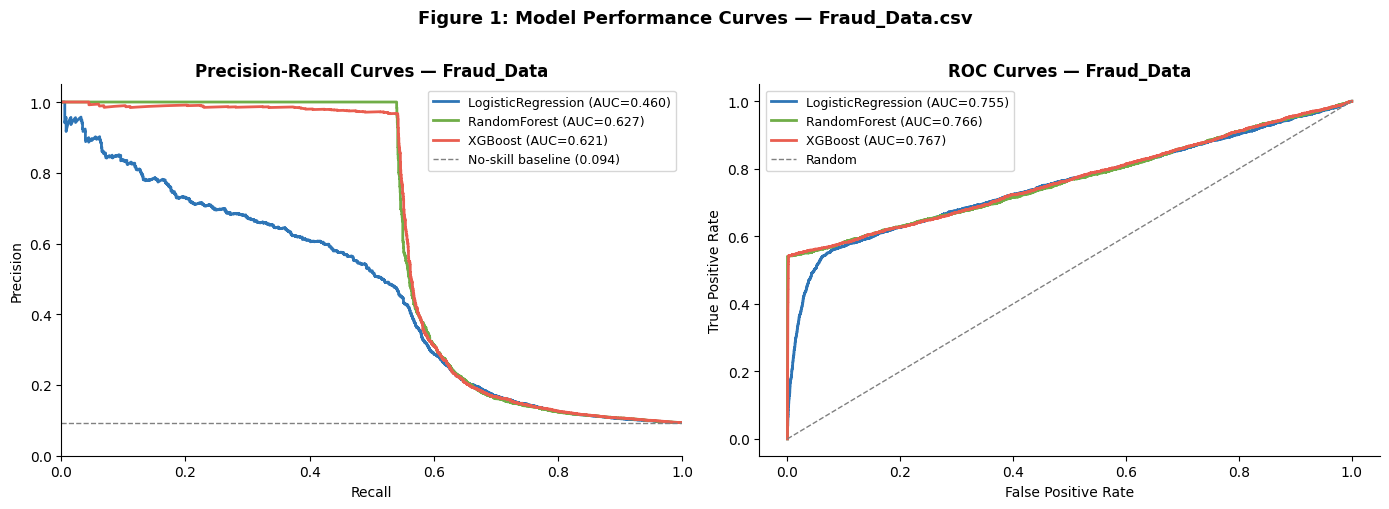

In [8]:
# Precision-Recall curves for all models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = [BLUE, GREEN, CORAL]

for (name, res), color in zip(fraud_results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_f_test, res['y_prob'])
    axes[0].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (AUC={res['pr_auc']:.3f})")

baseline = y_f_test.mean()
axes[0].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'No-skill baseline ({baseline:.3f})')
axes[0].set_title('Precision-Recall Curves — Fraud_Data', fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.05)

# ROC curves
for (name, res), color in zip(fraud_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_f_test, res['y_prob'])
    axes[1].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={res['roc_auc']:.3f})")

axes[1].plot([0,1],[0,1],'--',color='gray',lw=1,label='Random')
axes[1].set_title('ROC Curves — Fraud_Data', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 1: Model Performance Curves — Fraud_Data.csv',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/model_curves_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

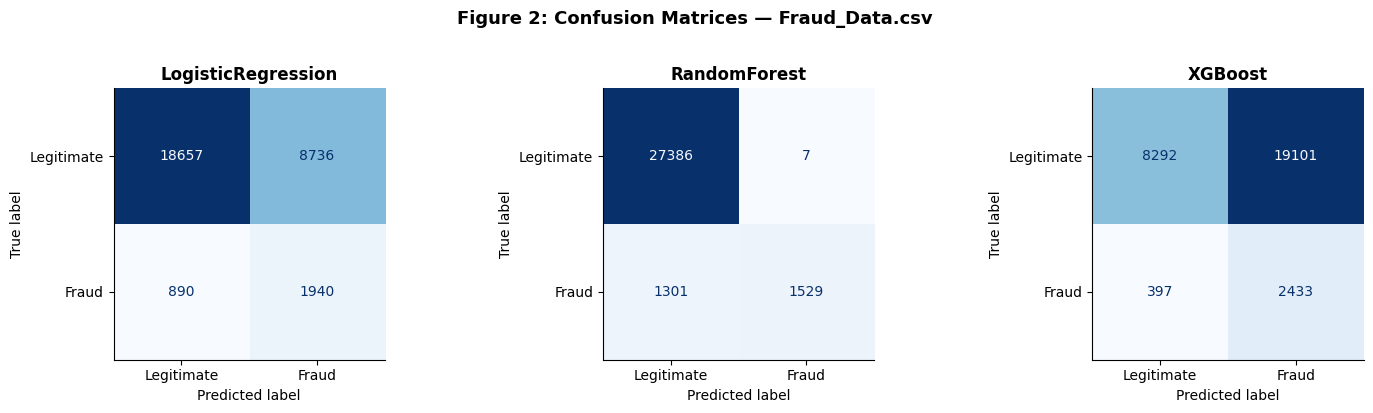

In [9]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, fraud_results.items()):
    disp = ConfusionMatrixDisplay(res['cm'], display_labels=['Legitimate','Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Figure 2: Confusion Matrices — Fraud_Data.csv',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/confusion_matrices_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cross-Validation — Fraud_Data.csv

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fraud_cv_results = []

for name, model in get_models(scale_pos_weight=9).items():
    print(f'CV: {name} ...')
    scores = cross_validate(model, X_f_train_sm, y_f_train_sm, cv=cv,
                            scoring={'pr_auc':'average_precision','f1':'f1'},
                            n_jobs=-1)
    fraud_cv_results.append({
        'Model':     name,
        'CV PR-AUC': f"{scores['test_pr_auc'].mean():.4f} ± {scores['test_pr_auc'].std():.4f}",
        'CV F1':     f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
    })

print('\n5-Fold Cross-Validation Results — Fraud_Data:')
print(pd.DataFrame(fraud_cv_results).to_string(index=False))

CV: LogisticRegression ...
CV: RandomForest ...
CV: XGBoost ...

5-Fold Cross-Validation Results — Fraud_Data:
             Model       CV PR-AUC           CV F1
LogisticRegression 0.8458 ± 0.0008 0.7195 ± 0.0008
      RandomForest 0.9578 ± 0.0013 0.8049 ± 0.0052
           XGBoost 0.9759 ± 0.0010 0.7381 ± 0.0044


---
## 7. Train and Evaluate — creditcard.csv

In [11]:
# creditcard is ~577:1 imbalanced — use higher scale_pos_weight
cc_results = {}
cc_models  = get_models(scale_pos_weight=577)

for name, model in cc_models.items():
    print(f'Training {name} on creditcard ...')
    model.fit(X_c_train_sm, y_c_train_sm)
    res = evaluate(model, X_c_test, y_c_test)
    cc_results[name] = res
    print(f'  ROC-AUC: {res["roc_auc"]:.4f} | PR-AUC: {res["pr_auc"]:.4f} | F1: {res["f1"]:.4f}')

print('\nDone.')

Training LogisticRegression on creditcard ...
  ROC-AUC: 0.9618 | PR-AUC: 0.6722 | F1: 0.1008
Training RandomForest on creditcard ...
  ROC-AUC: 0.9805 | PR-AUC: 0.7894 | F1: 0.6724
Training XGBoost on creditcard ...
  ROC-AUC: 0.9578 | PR-AUC: 0.7418 | F1: 0.1045

Done.


In [12]:
cc_table = pd.DataFrame([
    {'Model': k, 'ROC-AUC': f"{v['roc_auc']:.4f}",
     'PR-AUC': f"{v['pr_auc']:.4f}", 'F1': f"{v['f1']:.4f}"}
    for k, v in cc_results.items()
])
print('creditcard Model Comparison:')
print(cc_table.to_string(index=False))

creditcard Model Comparison:
             Model ROC-AUC PR-AUC     F1
LogisticRegression  0.9618 0.6722 0.1008
      RandomForest  0.9805 0.7894 0.6724
           XGBoost  0.9578 0.7418 0.1045


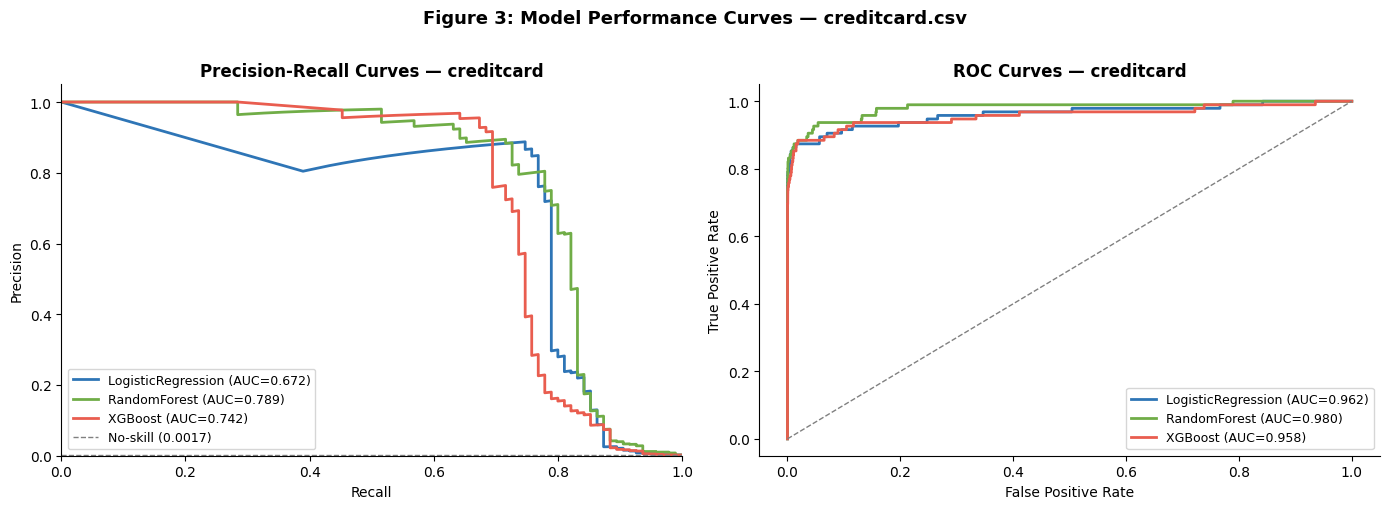

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, res), color in zip(cc_results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_c_test, res['y_prob'])
    axes[0].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (AUC={res['pr_auc']:.3f})")

baseline_cc = y_c_test.mean()
axes[0].axhline(baseline_cc, color='gray', linestyle='--', lw=1,
                label=f'No-skill ({baseline_cc:.4f})')
axes[0].set_title('Precision-Recall Curves — creditcard', fontweight='bold')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].legend(fontsize=9); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.05)

for (name, res), color in zip(cc_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_c_test, res['y_prob'])
    axes[1].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={res['roc_auc']:.3f})")
axes[1].plot([0,1],[0,1],'--',color='gray',lw=1)
axes[1].set_title('ROC Curves — creditcard', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 3: Model Performance Curves — creditcard.csv',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/model_curves_cc.png', dpi=150, bbox_inches='tight')
plt.show()

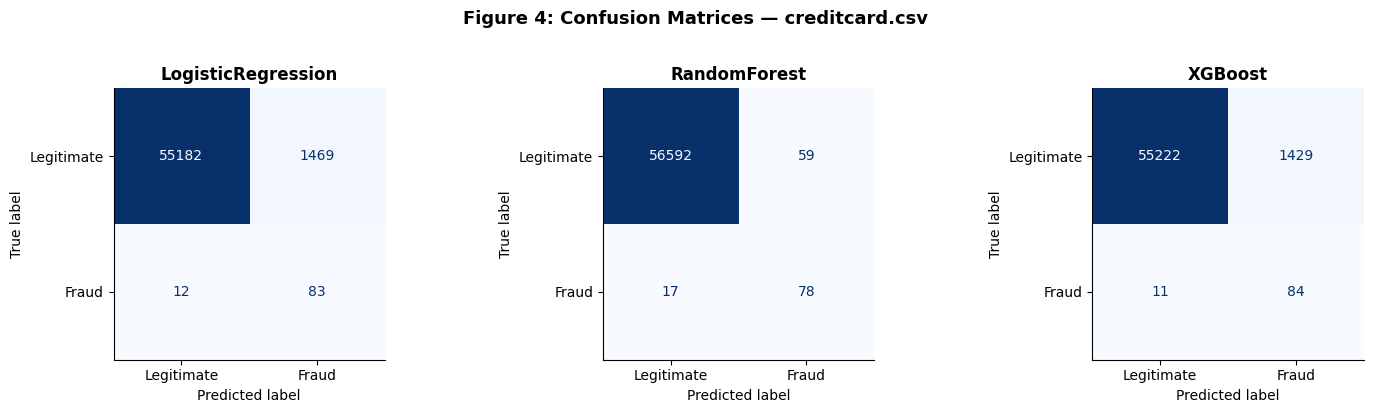

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, cc_results.items()):
    disp = ConfusionMatrixDisplay(res['cm'], display_labels=['Legitimate','Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Figure 4: Confusion Matrices — creditcard.csv',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/figures/confusion_matrices_cc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Cross-Validation — creditcard.csv

In [15]:
cc_cv_results = []
for name, model in get_models(scale_pos_weight=577).items():
    print(f'CV: {name} ...')
    scores = cross_validate(model, X_c_train_sm, y_c_train_sm, cv=cv,
                            scoring={'pr_auc':'average_precision','f1':'f1'},
                            n_jobs=-1)
    cc_cv_results.append({
        'Model':     name,
        'CV PR-AUC': f"{scores['test_pr_auc'].mean():.4f} ± {scores['test_pr_auc'].std():.4f}",
        'CV F1':     f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
    })

print('\n5-Fold CV Results — creditcard:')
print(pd.DataFrame(cc_cv_results).to_string(index=False))

CV: LogisticRegression ...
CV: RandomForest ...
CV: XGBoost ...

5-Fold CV Results — creditcard:
             Model       CV PR-AUC           CV F1
LogisticRegression 0.9919 ± 0.0002 0.9461 ± 0.0011
      RandomForest 0.9998 ± 0.0001 0.9902 ± 0.0003
           XGBoost 0.9999 ± 0.0000 0.9873 ± 0.0004


---
## 9. Model Comparison — Both Datasets

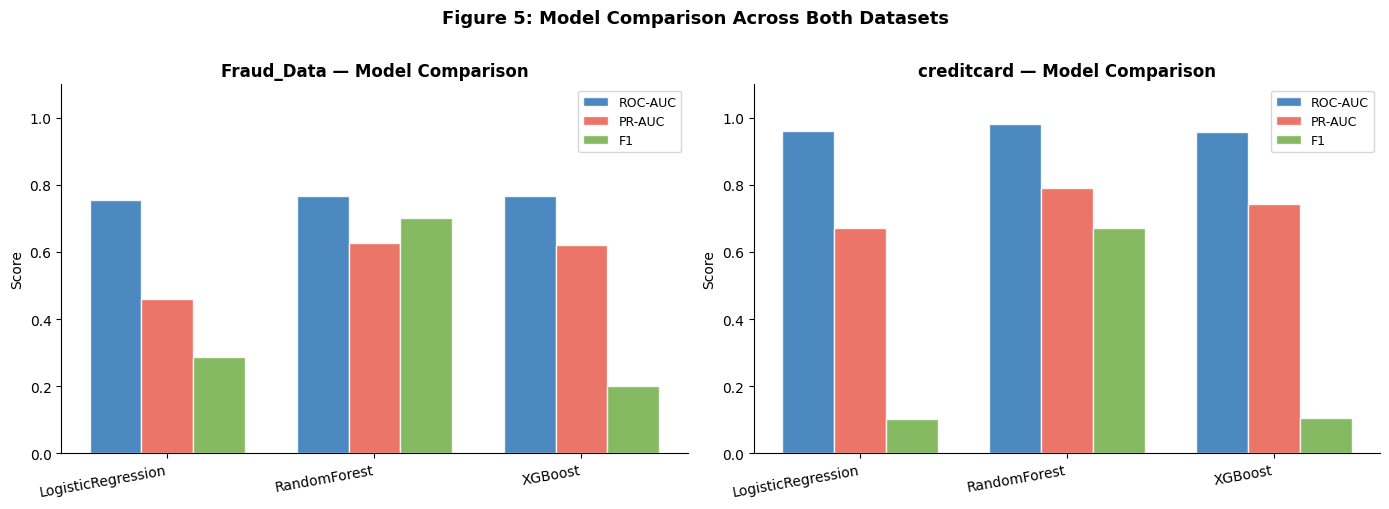

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = list(fraud_results.keys())
x = np.arange(len(model_names))
width = 0.25

# Fraud_Data
for i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),
                                       ('pr_auc','PR-AUC'),
                                       ('f1','F1')]):
    vals = [fraud_results[m][metric] for m in model_names]
    axes[0].bar(x + i*width, vals, width, label=label,
                color=[BLUE,CORAL,GREEN][i], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].set_title('Fraud_Data — Model Comparison', fontweight='bold')
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=9)

# creditcard
for i, (metric, label) in enumerate([('roc_auc','ROC-AUC'),
                                       ('pr_auc','PR-AUC'),
                                       ('f1','F1')]):
    vals = [cc_results[m][metric] for m in model_names]
    axes[1].bar(x + i*width, vals, width, label=label,
                color=[BLUE,CORAL,GREEN][i], alpha=0.85, edgecolor='white')

axes[1].set_xticks(x + width)
axes[1].set_xticklabels(model_names, rotation=10, ha='right')
axes[1].set_title('creditcard — Model Comparison', fontweight='bold')
axes[1].set_ylabel('Score'); axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)

plt.suptitle('Figure 5: Model Comparison Across Both Datasets',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../notebooks/figures/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Select and Save Best Models

In [17]:
# Select best by PR-AUC (primary metric for imbalanced data)
best_fraud_name = max(fraud_results, key=lambda k: fraud_results[k]['pr_auc'])
best_cc_name    = max(cc_results,    key=lambda k: cc_results[k]['pr_auc'])

best_fraud_model = fraud_models[best_fraud_name]
best_cc_model    = cc_models[best_cc_name]

print(f'Best Fraud_Data model: {best_fraud_name}')
print(f'  PR-AUC: {fraud_results[best_fraud_name]["pr_auc"]:.4f}')
print(f'  F1:     {fraud_results[best_fraud_name]["f1"]:.4f}')
print()
print(f'Best creditcard model: {best_cc_name}')
print(f'  PR-AUC: {cc_results[best_cc_name]["pr_auc"]:.4f}')
print(f'  F1:     {cc_results[best_cc_name]["f1"]:.4f}')

# Save
with open('../models/fraud_best_model.pkl','wb') as f:
    pickle.dump(best_fraud_model, f)
with open('../models/cc_best_model.pkl','wb') as f:
    pickle.dump(best_cc_model, f)
with open('../models/fraud_X_test.pkl','wb') as f:
    pickle.dump((X_f_test, y_f_test), f)
with open('../models/cc_X_test.pkl','wb') as f:
    pickle.dump((X_c_test, y_c_test), f)

print('\nModels saved to models/')

Best Fraud_Data model: RandomForest
  PR-AUC: 0.6267
  F1:     0.7004

Best creditcard model: RandomForest
  PR-AUC: 0.7894
  F1:     0.6724

Models saved to models/


## 11. Model Selection Justification

### Primary Evaluation Metric: Precision-Recall AUC (PR-AUC)

Fraud detection is an inherently imbalanced classification problem. In such settings, ROC-AUC can be misleading because the large number of legitimate transactions inflates the true negative rate, often producing optimistic performance estimates. Precision-Recall AUC (PR-AUC) focuses specifically on the model's ability to identify fraudulent transactions while minimizing false alarms, making it a more appropriate metric for model selection.

In addition to PR-AUC, F1-score was used as a supporting metric because it provides a single-number summary of the balance between precision and recall. Therefore, the final model selection was based primarily on PR-AUC and supported by F1-score performance on the held-out test set.

### Fraud_Data.csv — Best Model: Random Forest

Random Forest achieved the strongest overall performance on the Fraud_Data test set, with a PR-AUC of **0.6267** and an F1-score of **0.7004**. Although XGBoost produced a marginally higher ROC-AUC (**0.7675** versus **0.7658**), its F1-score dropped substantially to **0.1997**, indicating poor threshold-level classification performance.

The results suggest that Random Forest captures the non-linear relationships present in the engineered fraud features while maintaining better generalization on unseen transactions. Compared with Logistic Regression, Random Forest substantially improved both fraud detection capability and the balance between precision and recall. As a result, Random Forest was selected as the preferred model for Fraud_Data.csv.

### creditcard.csv — Best Model: Random Forest

Random Forest also achieved the highest performance on the creditcard dataset, obtaining a PR-AUC of **0.7894** and an F1-score of **0.6724**. Despite the extreme class imbalance of approximately **577:1**, the model maintained a strong balance between identifying fraudulent transactions and limiting false positives.

Logistic Regression and XGBoost achieved reasonable ROC-AUC scores; however, their F1-scores remained close to **0.10**, indicating that their classification thresholds produced considerably weaker fraud detection performance. Because PR-AUC is the primary evaluation criterion for highly imbalanced datasets, Random Forest was selected as the best-performing model for creditcard.csv.

### Cross-Validation versus Test Performance

Cross-validation results showed exceptionally strong performance for both Random Forest and XGBoost on the SMOTE-balanced training data. XGBoost achieved the highest mean cross-validation PR-AUC on both datasets, reaching **0.9759** on Fraud_Data and **0.9999** on creditcard.csv.

However, model selection was intentionally based on performance on the untouched test sets rather than cross-validation scores alone. While XGBoost excelled during cross-validation, Random Forest consistently delivered superior PR-AUC and F1-score performance on unseen data. This indicates that Random Forest generalized more effectively and provides a more reliable choice for deployment.

### Interpretability Considerations

Logistic Regression remains the most interpretable model and serves as an important benchmark for regulatory and compliance purposes. Its coefficients can be directly linked to prediction outcomes, making model behavior easier to explain.

However, the substantial performance gap between Logistic Regression and Random Forest makes the latter the more suitable operational model. To address interpretability concerns, feature importance analysis and SHAP-based explainability can be applied to Random Forest predictions, enabling transparent investigation of fraud decisions while preserving predictive performance.

### Deployment Recommendation

Based on the evaluation results, **Random Forest is recommended as the production model for both Fraud_Data.csv and creditcard.csv**. The model achieved the highest PR-AUC and F1-score on both test sets, demonstrating the strongest balance between fraud detection effectiveness and false-positive control.

Logistic Regression should be retained as a benchmark and compliance reference model, while Random Forest should be monitored in production using ongoing performance tracking and SHAP-based explanations to ensure transparency, stability, and continued business value.
